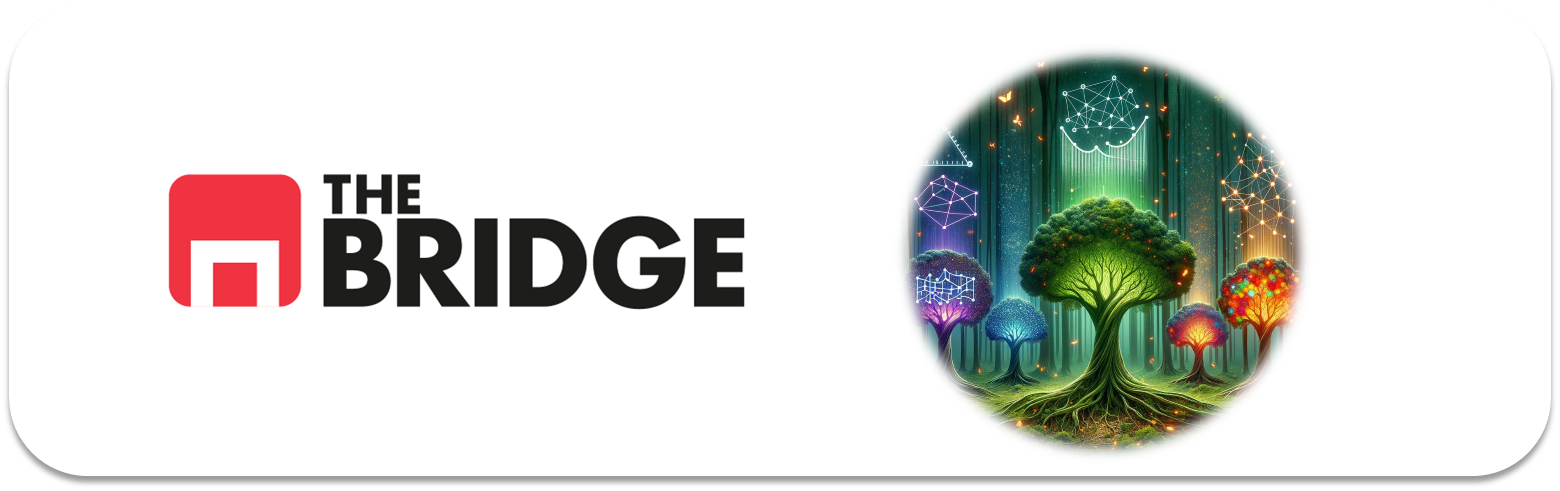

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [6]:
df = pd.read_csv("./data/bank-full.csv", sep=";")

In [8]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [11]:
df.value_counts("poutcome")

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

Hay demasiados como para eliminarlos, veamos en la columna contact, job y en education

In [12]:
df.value_counts("contact")

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [13]:
df.value_counts("education")

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [14]:
df.value_counts("job")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Unknown se puede tratar como una variable categórica más

Veamos ahora de manera gráfica los valores de la variable target: 

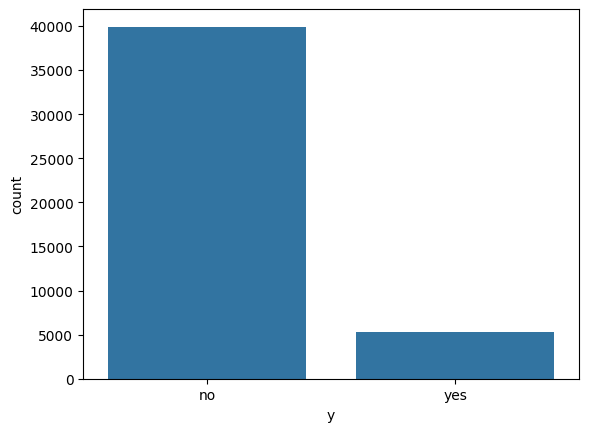

In [17]:
sns.countplot(data=df, x='y');

Hay una clara infrarrepresentación de la clase "yes", por lo que habrá que tenerlo en cuenta para la división entre train y test:

In [18]:
X = df[['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']]

# Target
y = df['y']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=df['y'],
    random_state=42
)

In [52]:
columnas_categoricas = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
columnas_num = X_train.select_dtypes(include=['float', 'int64']).columns.tolist()

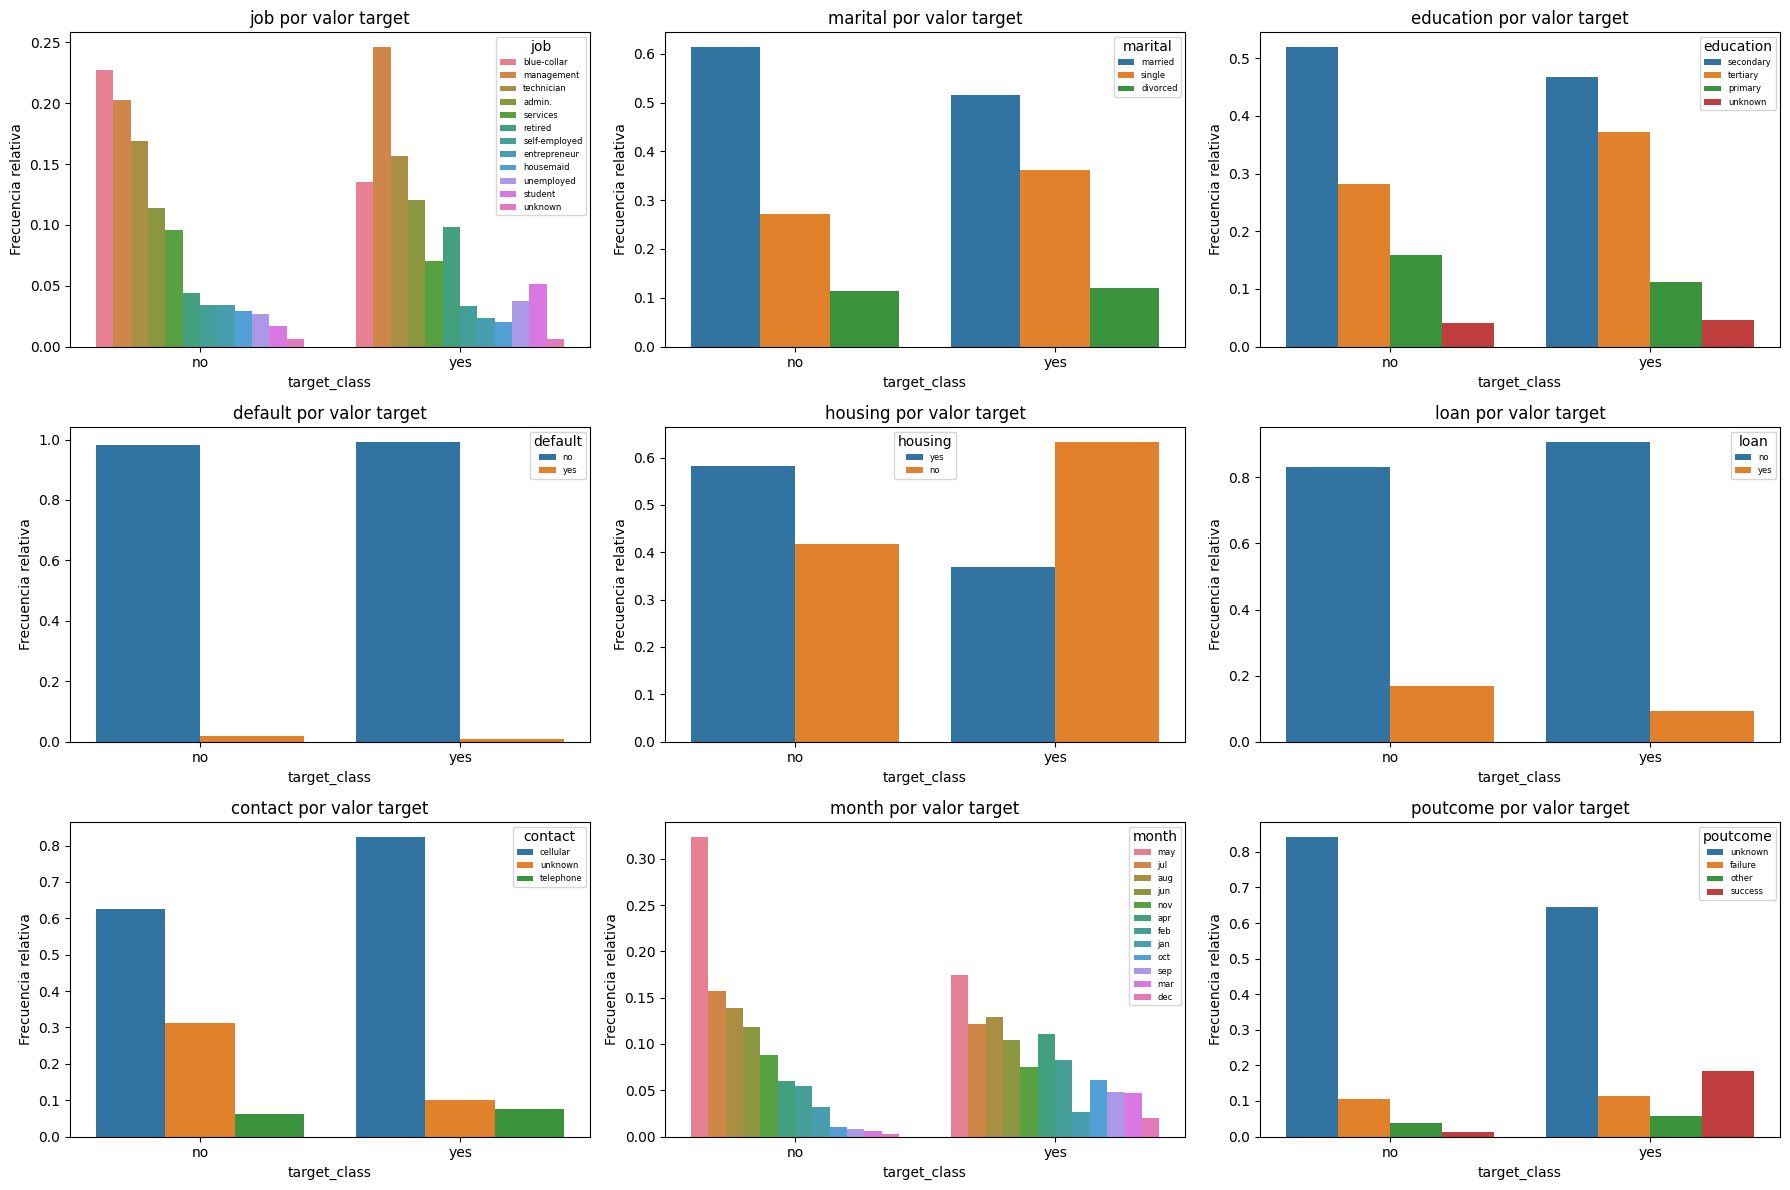

In [28]:
n_cols = 3
n_rows = int(np.ceil(len(columnas_categoricas) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()  # por si solo hay 1 fila/columna

for i, col in enumerate(columnas_categoricas):
    temp_df = pd.DataFrame({
        'target_class': y_train.astype(str),
        'categoria': X_train[col].astype(str)
    })

    freq = (
        temp_df.groupby('target_class')['categoria']
        .value_counts(normalize=True)
        .rename('freq_relativa')
        .reset_index()
    )

    sns.barplot(data=freq, x='target_class', y='freq_relativa', hue='categoria', ax=axes[i])
    axes[i].set_title(f'{col} por valor target')
    axes[i].set_ylabel('Frecuencia relativa')
    axes[i].legend(fontsize=6, title=col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

La columna default tiene prácticamente la misma distribución entre ambas clases de la variable target, por lo que se puede eliminar. Pero vamos antes a realizar un test de significacia, para asegurarnos

In [29]:
only_categorical = X_train[columnas_categoricas]

In [31]:
for col in only_categorical.columns:
    tabla = pd.crosstab(only_categorical[col], y_train)
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"{col}: Chi2={chi2:.4f}, p-valor={p:.4f}")

job: Chi2=686.9717, p-valor=0.0000
marital: Chi2=168.0022, p-valor=0.0000
education: Chi2=177.0408, p-valor=0.0000
default: Chi2=21.0686, p-valor=0.0000
housing: Chi2=702.2741, p-valor=0.0000
loan: Chi2=159.4996, p-valor=0.0000
contact: Chi2=813.5186, p-valor=0.0000
month: Chi2=2395.2054, p-valor=0.0000
poutcome: Chi2=3480.4530, p-valor=0.0000


Según chi2, sí que existen diferencias significativas entre ambas clases de la variable target, así que la mantenemos

In [35]:
from scipy.stats import ttest_ind
only_numerical = X_train.drop(columns=columnas_categoricas).copy()

clases = y_train.unique()

for col in only_numerical.columns:
        grupo_0 = only_numerical[col][y_train == clases[0]]
        grupo_1 = only_numerical[col][y_train == clases[1]]
        
        t_stat, p = ttest_ind(grupo_0, grupo_1)
        print(f"{col}: t={t_stat:.4f}, p-valor={p:.4f}")

age: t=-4.6995, p-valor=0.0000
balance: t=-10.4801, p-valor=0.0000
day: t=5.0595, p-valor=0.0000
duration: t=-82.1956, p-valor=0.0000
campaign: t=13.7239, p-valor=0.0000
pdays: t=-19.2490, p-valor=0.0000
previous: t=-16.9634, p-valor=0.0000


Tampoco encuentra diferencias no significativas, así que las mantenemos todas

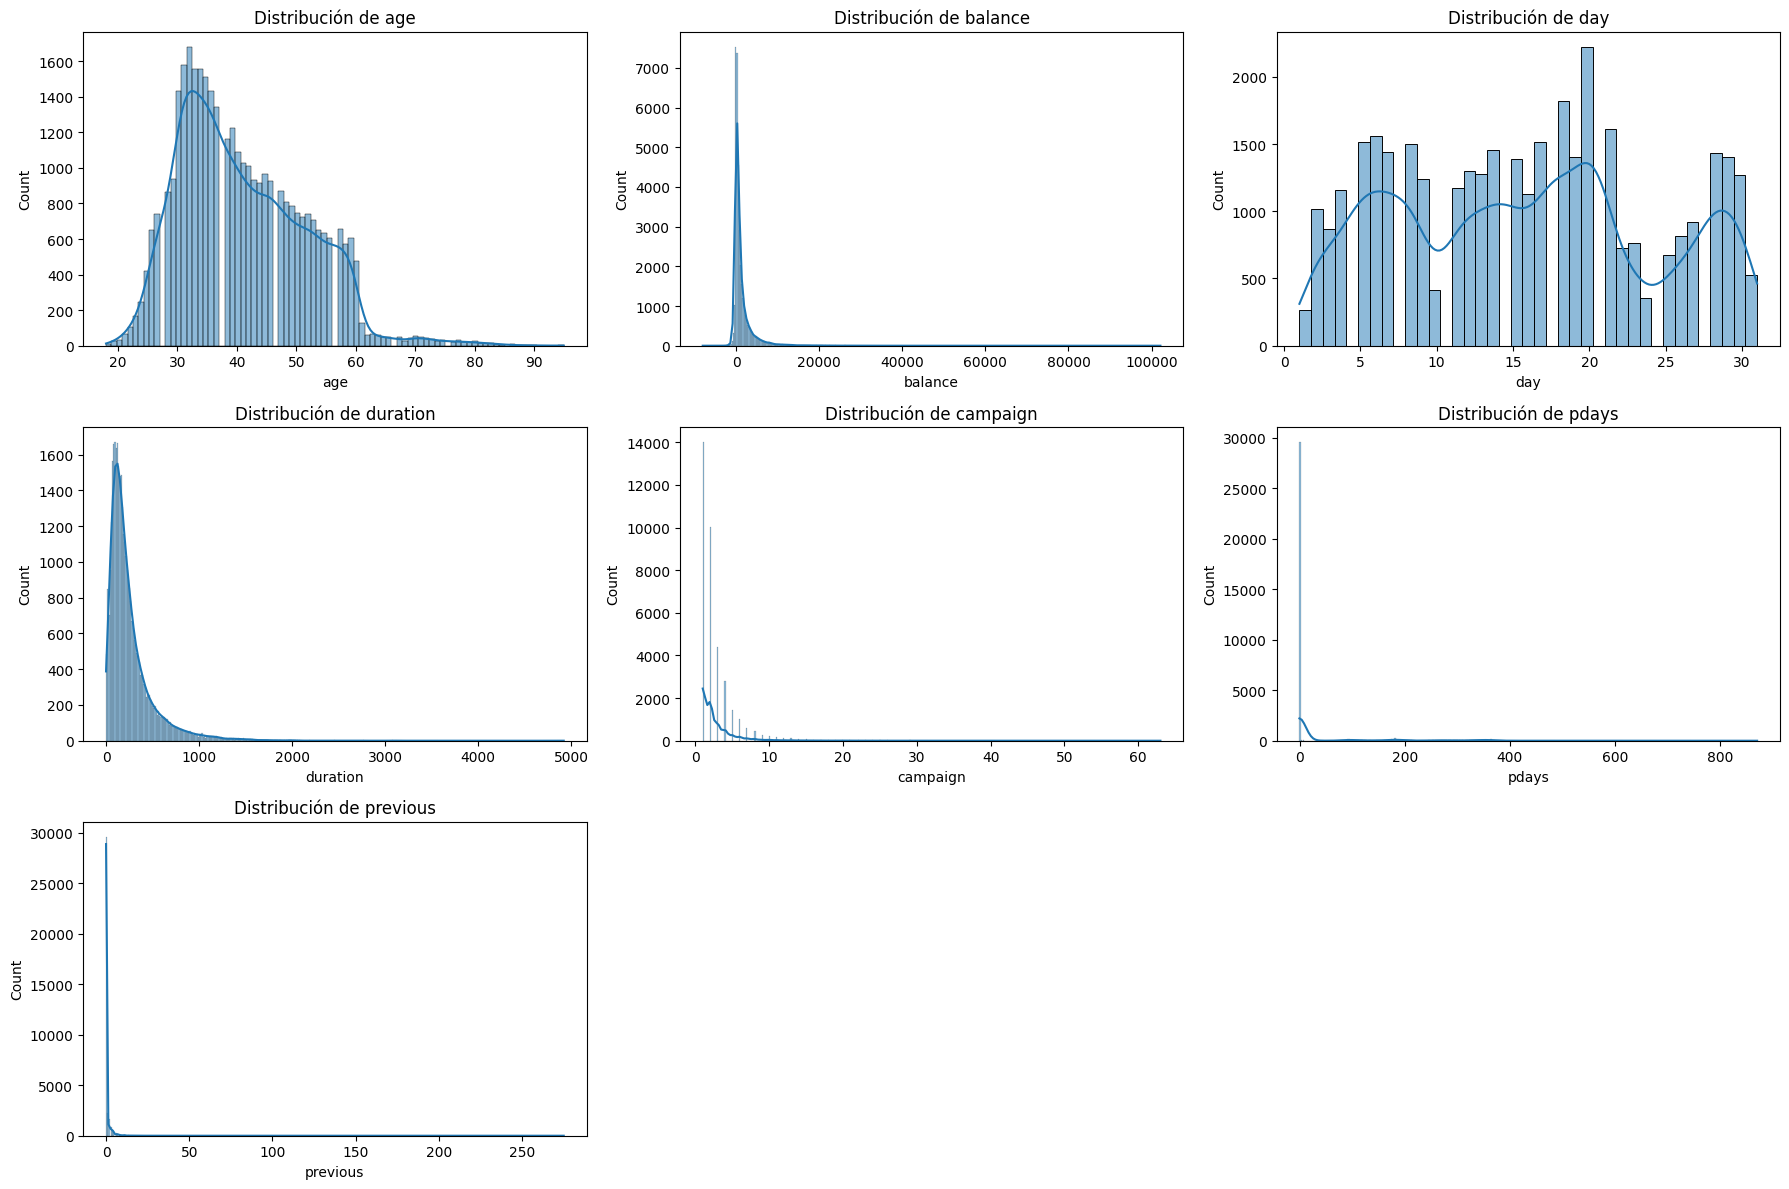

In [36]:
n_cols = 3
n_rows = int(np.ceil(len(only_numerical.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(only_numerical.columns):
    sns.histplot(only_numerical[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

No todas las variables numéricas siguen una distribución normal, pero como vamos a usar primero un árbol de decisión no normalizaremos, lo haremos cuando apliquemos la regresión logística.

In [39]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train[columnas_categoricas])

# reconstruir DataFrames con nombres de columnas
X_train_cat = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(columnas_categoricas), index=X_train.index)

# unir con las columnas numéricas
X_train_def = pd.concat([X_train.drop(columns=columnas_categoricas), X_train_cat], axis=1)

Aplicamos los árboles de decisión

In [40]:
tree_clf = DecisionTreeClassifier(max_depth=2,
                                  random_state=42)
tree_clf.fit(X_train_def, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Y ahora preparamos X_test para enfrentarlo al modelo

In [42]:
X_test_cat = encoder.fit_transform(X_test[columnas_categoricas])

# reconstruir DataFrames con nombres de columnas
X_test_cat = pd.DataFrame(X_test_cat, columns=encoder.get_feature_names_out(columnas_categoricas), index=X_test.index)

# unir con las columnas numéricas
X_test_def = pd.concat([X_test.drop(columns=columnas_categoricas), X_test_cat], axis=1)

In [43]:
y_pred = tree_clf.predict(X_test_def)

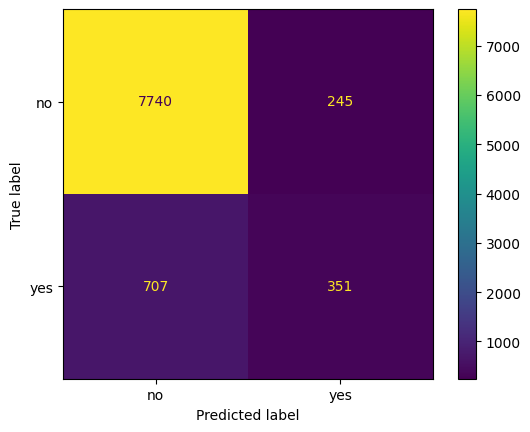

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Vemos que los verdaderos positivos y negativos superan a los falsos popsitivos y negativos.

Como métrica de análisis, vamos a evaluarlo con Recall o F1, ya que partíamos de una muestra desequilibrada

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.92      0.97      0.94      7985
         yes       0.59      0.33      0.42      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.65      0.68      9043
weighted avg       0.88      0.89      0.88      9043



El modelo predice muy bien los negativos pero no tan bien los positivos (por desequilibrio muestral probablemente)

Pasamos a comparar estos resultados con una regresión logística

In [49]:
X_train_copy = X_train.copy()

In [ ]:
scaler = StandardScaler()
X_train_copy[columnas_num] = scaler.fit_transform(X_train_copy[columnas_num])

In [50]:
X_train_cat = encoder.fit_transform(X_train_copy[columnas_categoricas])

# reconstruir DataFrames con nombres de columnas
X_train_cat = pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(columnas_categoricas), index=X_train_copy.index)

# unir con las columnas numéricas
X_train_def = pd.concat([X_train_copy.drop(columns=columnas_categoricas), X_train_cat], axis=1)

In [53]:
clf = LogisticRegression(max_iter=10000) 

clf.fit(X_train_def, y_train)

c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
X_test_copy = X_test.copy()

X_test_copy[columnas_num] = scaler.fit_transform(X_test_copy[columnas_num])

In [55]:
X_test_cat = encoder.fit_transform(X_test_copy[columnas_categoricas])

# reconstruir DataFrames con nombres de columnas
X_test_cat = pd.DataFrame(X_test_cat, columns=encoder.get_feature_names_out(columnas_categoricas), index=X_test.index)

# unir con las columnas numéricas
X_test_def = pd.concat([X_test_copy.drop(columns=columnas_categoricas), X_test_cat], axis=1)

In [56]:
y_pred = clf.predict(X_test_def)

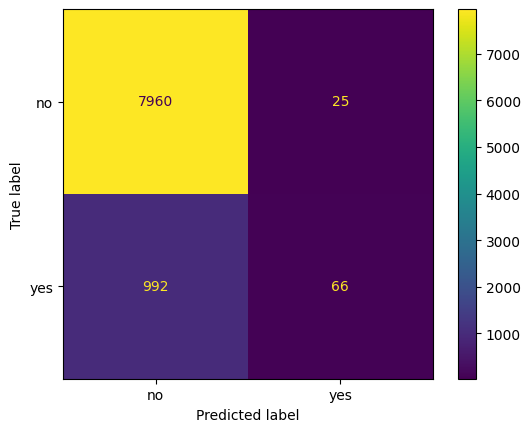

In [57]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7985
         yes       0.73      0.06      0.11      1058

    accuracy                           0.89      9043
   macro avg       0.81      0.53      0.53      9043
weighted avg       0.87      0.89      0.84      9043



Vemos que tenemos sustancialmente menos falsos positivos y más falsos negativos, según la matriz de confusión. Las métricas de regresión logística tanto de recall como el f1-score también son peores en cuanto a los positivos que las obtenidas con los árboles de decisión, por lo que escogería el modelo de árboles para seguir optimizándolo.